In [1]:
# Netflix SQL Analysis
#Using SQLite + Pandas + Matplotlib


import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
conn = sqlite3.connect("netflix.db")

In [11]:
query = "SELECT * FROM netflix LIMIT 5;"
pd.read_sql(query, conn)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,country_clean,content_age
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25 00:00:00,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,United States,1.0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24 00:00:00,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,South Africa,0.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24 00:00:00,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,Unknown,0.0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24 00:00:00,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,Unknown,0.0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24 00:00:00,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,India,0.0


In [7]:
query = """
SELECT type, COUNT(*) as count
FROM netflix
GROUP BY type;
"""

df_sql = pd.read_sql(query, conn)
df_sql

,type,count
0,Movie,6128
1,TV Show,2666


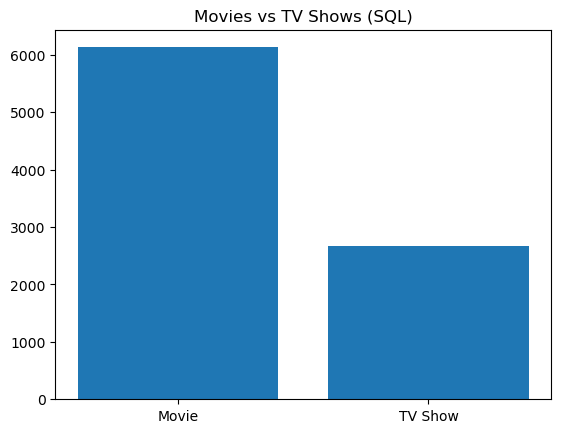

In [9]:
plt.figure()
plt.bar(df_sql['type'], df_sql['count'])
plt.title("Movies vs TV Shows (SQL)")
plt.show()

In [18]:
query = """
SELECT country, COUNT(*) as total
FROM netflix
GROUP BY country
ORDER BY total DESC
LIMIT 5;
"""

pd.read_sql(query, conn)

,country,total
0,United States,2809
1,India,972
2,Unknown,830
3,United Kingdom,418
4,Japan,244


In [20]:
query = """
SELECT year_added, COUNT(*) as total
FROM netflix
GROUP BY year_added
ORDER BY year_added;
"""

pd.read_sql(query, conn)

,year_added,total
0,NaN,88
1,2008.0,2
2,2009.0,2
3,2010.0,1
4,2011.0,13
5,2012.0,3
6,2013.0,10
7,2014.0,23
8,2015.0,73
9,2016.0,416


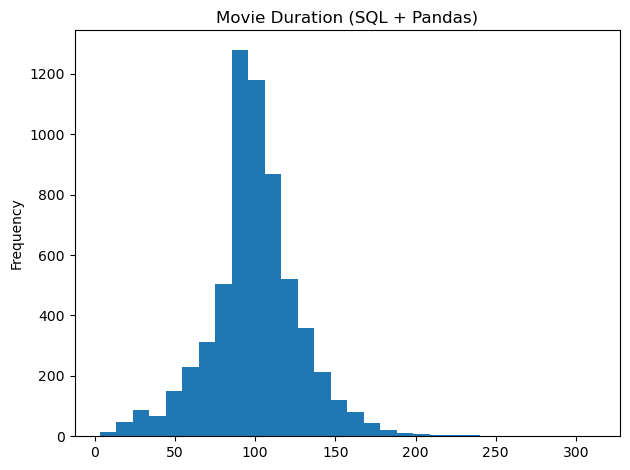

In [22]:
query = """
SELECT duration
FROM netflix
WHERE type = 'Movie';
"""

movies_sql = pd.read_sql(query, conn)

movies_sql['duration'] = movies_sql['duration'].str.replace(' min', '').astype(float)

movies_sql['duration'].plot(kind='hist', bins=30)

plt.title("Movie Duration (SQL + Pandas)")
plt.tight_layout()
plt.savefig("images/sql_duration.png")
plt.show()